# supp_fig - Part 3/5\n\n自动拆分版本（按步骤执行）。\n包含统一 bootstrap 和共享模块导入。\n

In [ ]:
# AUTO_BOOTSTRAP_V2
from pathlib import Path
import sys
import os
import builtins
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "projects").exists():
    cur = Path.cwd().resolve()
    for p in [cur] + list(cur.parents):
        if (p / "projects").exists():
            ROOT = p
            break

NB_PATH = Path.cwd()
if "clone_motif" in str(NB_PATH):
    PROJECT_DIR = ROOT / "projects" / "clone_motif"
else:
    PROJECT_DIR = ROOT / "projects" / "our_multiregion_motif"

DATA_RAW = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
OUT_FIG = PROJECT_DIR / "outputs" / "figures"
OUT_TABLE = PROJECT_DIR / "outputs" / "tables"
OUT_ARCH = PROJECT_DIR / "outputs" / "archives"

for d in [DATA_PROCESSED, OUT_FIG, OUT_TABLE, OUT_ARCH]:
    d.mkdir(parents=True, exist_ok=True)

SHARED_SRC = ROOT / "projects" / "shared" / "src"
if str(SHARED_SRC) not in sys.path:
    sys.path.append(str(SHARED_SRC))

from motif_common import combination, indices_for_region, union_indices_for_regions, p_to_star, format_p_decimal_3sig, sort_by_order, truncate_colormap

READ_EXT = {".csv", ".json", ".npy", ".pkl", ".xlsx"}
FIG_EXT = {".svg", ".png", ".pdf"}
TABLE_EXT = {".csv", ".xlsx"}


def _as_path(x):
    return Path(x) if isinstance(x, (str, os.PathLike)) else x


def resolve_read_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute() or p.exists():
        return str(p)
    if p.suffix.lower() in READ_EXT:
        for c in [DATA_RAW / p.name, ROOT / p.name]:
            if c.exists():
                return str(c)
    return str(p)


def resolve_write_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute():
        p.parent.mkdir(parents=True, exist_ok=True)
        return str(p)
    ext = p.suffix.lower()
    if ext in FIG_EXT:
        out = OUT_FIG / p.name
    elif ext in TABLE_EXT:
        out = OUT_TABLE / p.name
    elif ext == ".zip":
        out = OUT_ARCH / p.name
    elif ext == ".npy":
        out = DATA_PROCESSED / p.name
    else:
        out = PROJECT_DIR / p
    out.parent.mkdir(parents=True, exist_ok=True)
    return str(out)

if not hasattr(builtins, "_orig_open_codex"):
    builtins._orig_open_codex = builtins.open


def _open_patch(file, mode="r", *args, **kwargs):
    if isinstance(file, (str, os.PathLike)):
        if any(m in mode for m in ["r", "a"]):
            file = resolve_read_path(file)
        if any(m in mode for m in ["w", "a", "x"]):
            file = resolve_write_path(file)
    return builtins._orig_open_codex(file, mode, *args, **kwargs)


builtins.open = _open_patch

if not hasattr(np, "_orig_load_codex"):
    np._orig_load_codex = np.load
np.load = lambda file, *a, **k: np._orig_load_codex(resolve_read_path(file), *a, **k)

if not hasattr(np, "_orig_save_codex"):
    np._orig_save_codex = np.save
np.save = lambda file, arr, *a, **k: np._orig_save_codex(resolve_write_path(file), arr, *a, **k)

if not hasattr(pd, "_orig_read_csv_codex"):
    pd._orig_read_csv_codex = pd.read_csv
pd.read_csv = lambda f, *a, **k: pd._orig_read_csv_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd, "_orig_read_excel_codex"):
    pd._orig_read_excel_codex = pd.read_excel
pd.read_excel = lambda f, *a, **k: pd._orig_read_excel_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd.DataFrame, "_orig_to_csv_codex"):
    pd.DataFrame._orig_to_csv_codex = pd.DataFrame.to_csv


def _to_csv_patch(self, path_or_buf=None, *args, **kwargs):
    if isinstance(path_or_buf, (str, os.PathLike)):
        path_or_buf = resolve_write_path(path_or_buf)
    return pd.DataFrame._orig_to_csv_codex(self, path_or_buf, *args, **kwargs)


pd.DataFrame.to_csv = _to_csv_patch

if not hasattr(pd.DataFrame, "_orig_to_excel_codex"):
    pd.DataFrame._orig_to_excel_codex = pd.DataFrame.to_excel


def _to_excel_patch(self, excel_writer, *args, **kwargs):
    if isinstance(excel_writer, (str, os.PathLike)):
        excel_writer = resolve_write_path(excel_writer)
    return pd.DataFrame._orig_to_excel_codex(self, excel_writer, *args, **kwargs)


pd.DataFrame.to_excel = _to_excel_patch

try:
    import matplotlib.pyplot as plt
    if not hasattr(plt, "_orig_savefig_codex"):
        plt._orig_savefig_codex = plt.savefig
    plt.savefig = lambda f, *a, **k: plt._orig_savefig_codex(resolve_write_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)
except Exception:
    pass

print(f"[bootstrap] project={PROJECT_DIR.name} data={DATA_RAW}")


Saved figure: 6.MOp_motif_frequency_vs_param.svg


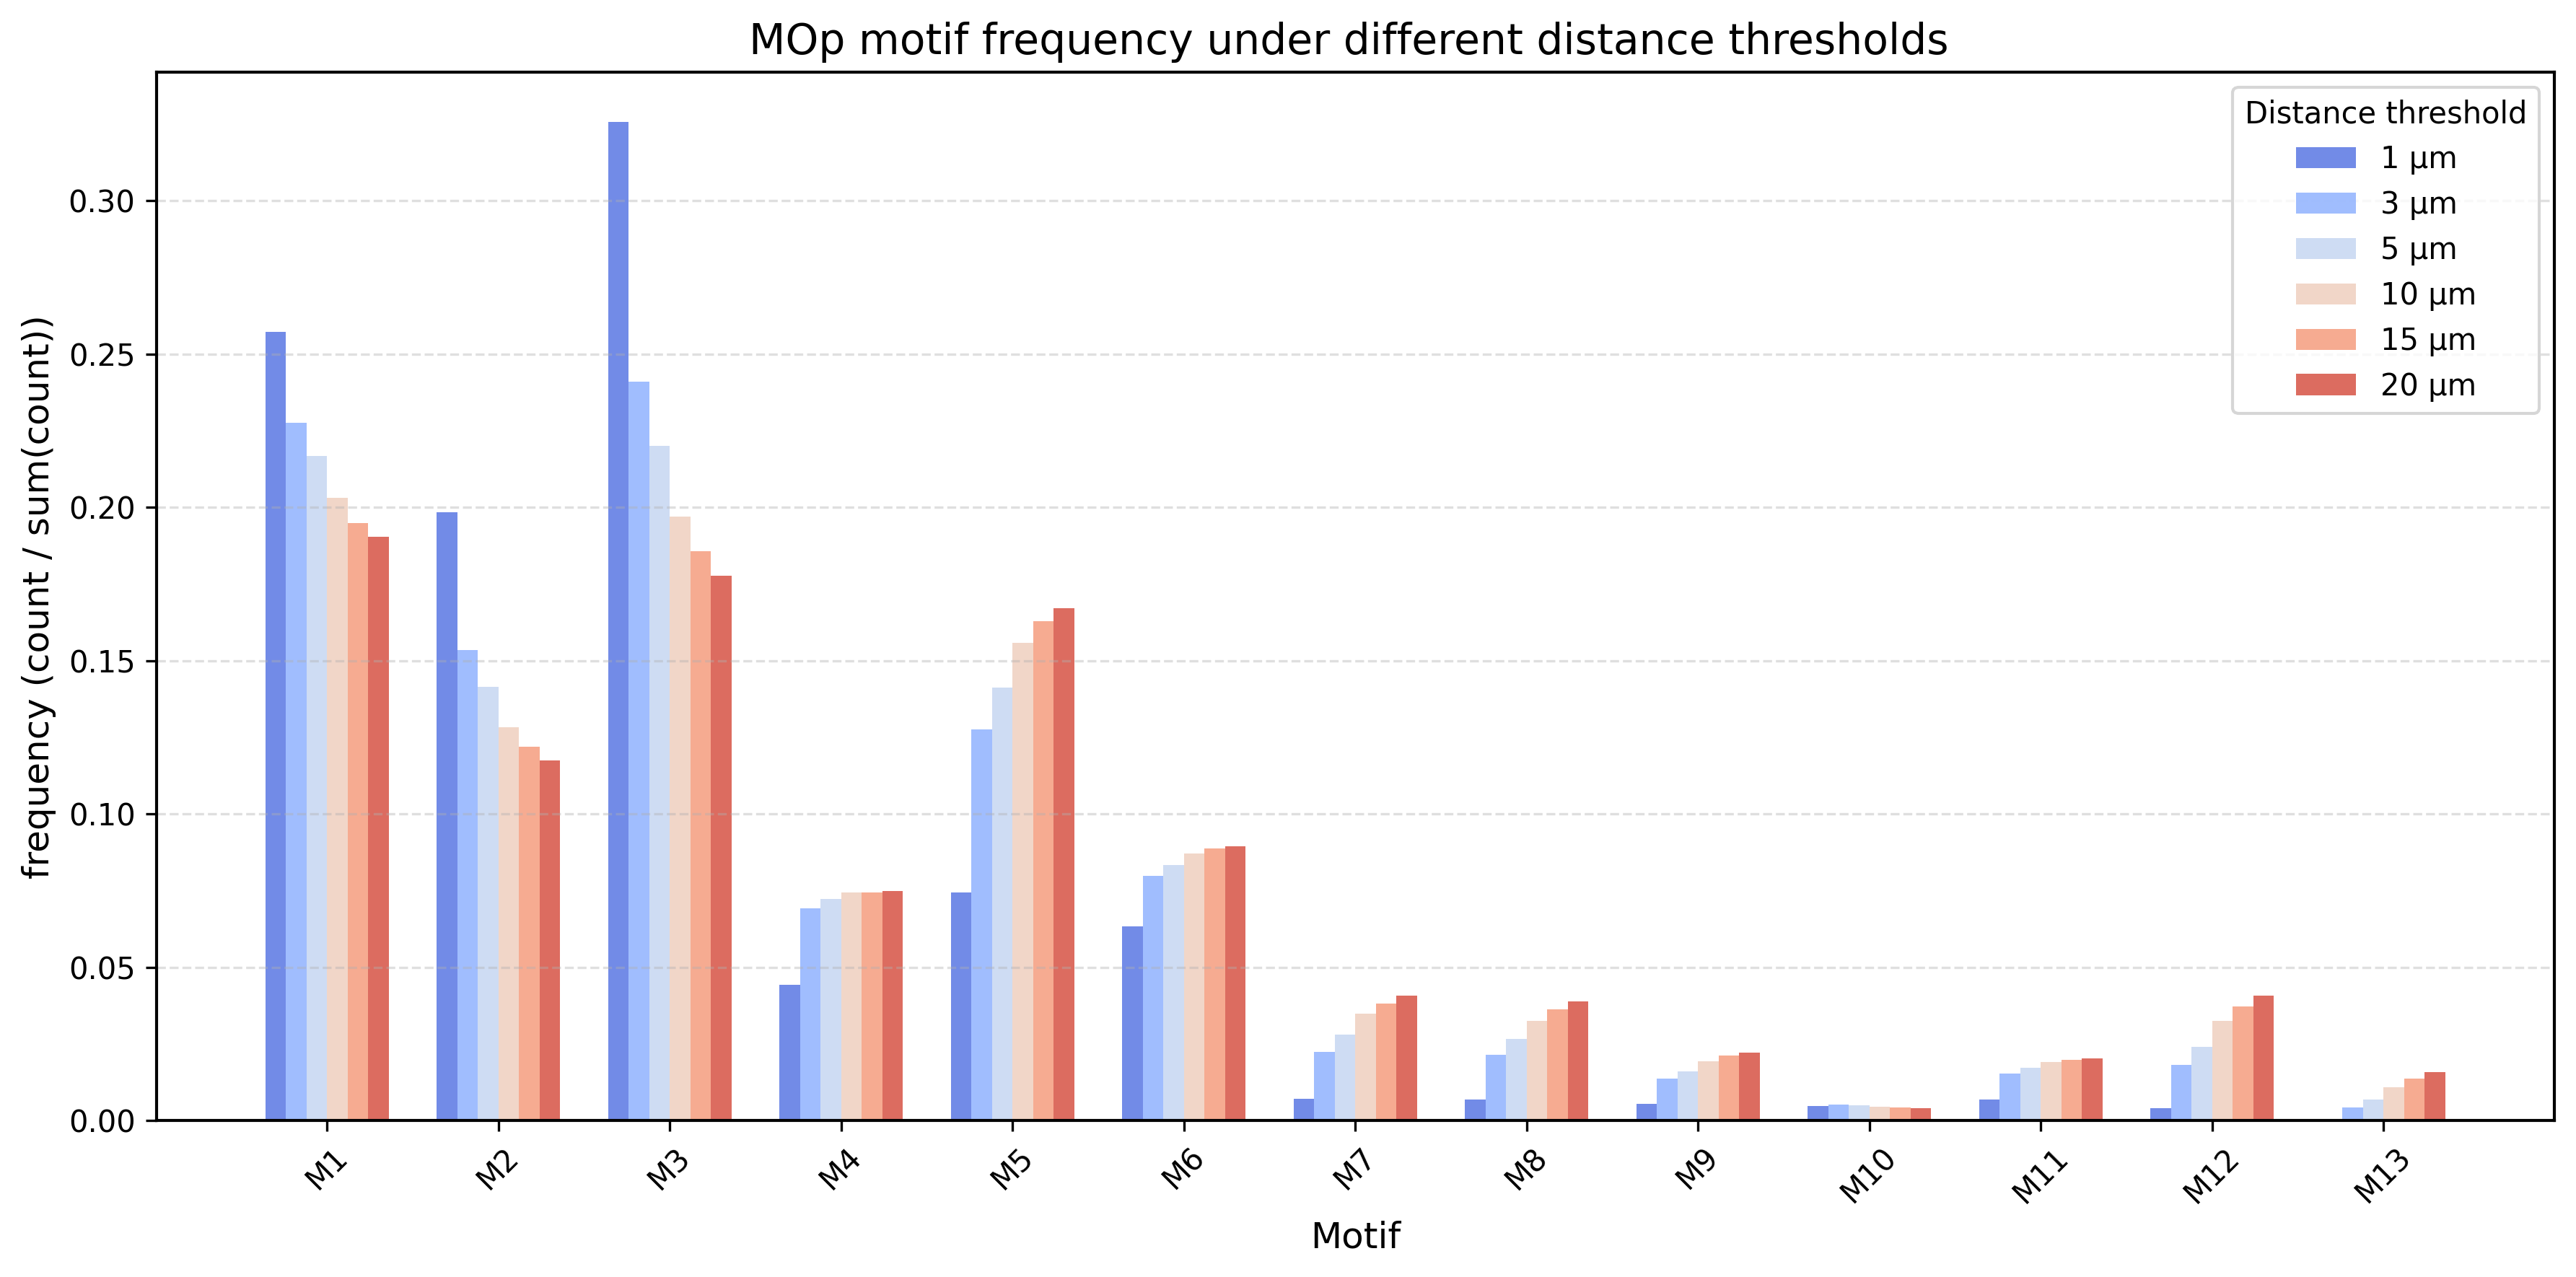

Saved figure: 6.MOp_motif_NZ_ER_vs_param.svg


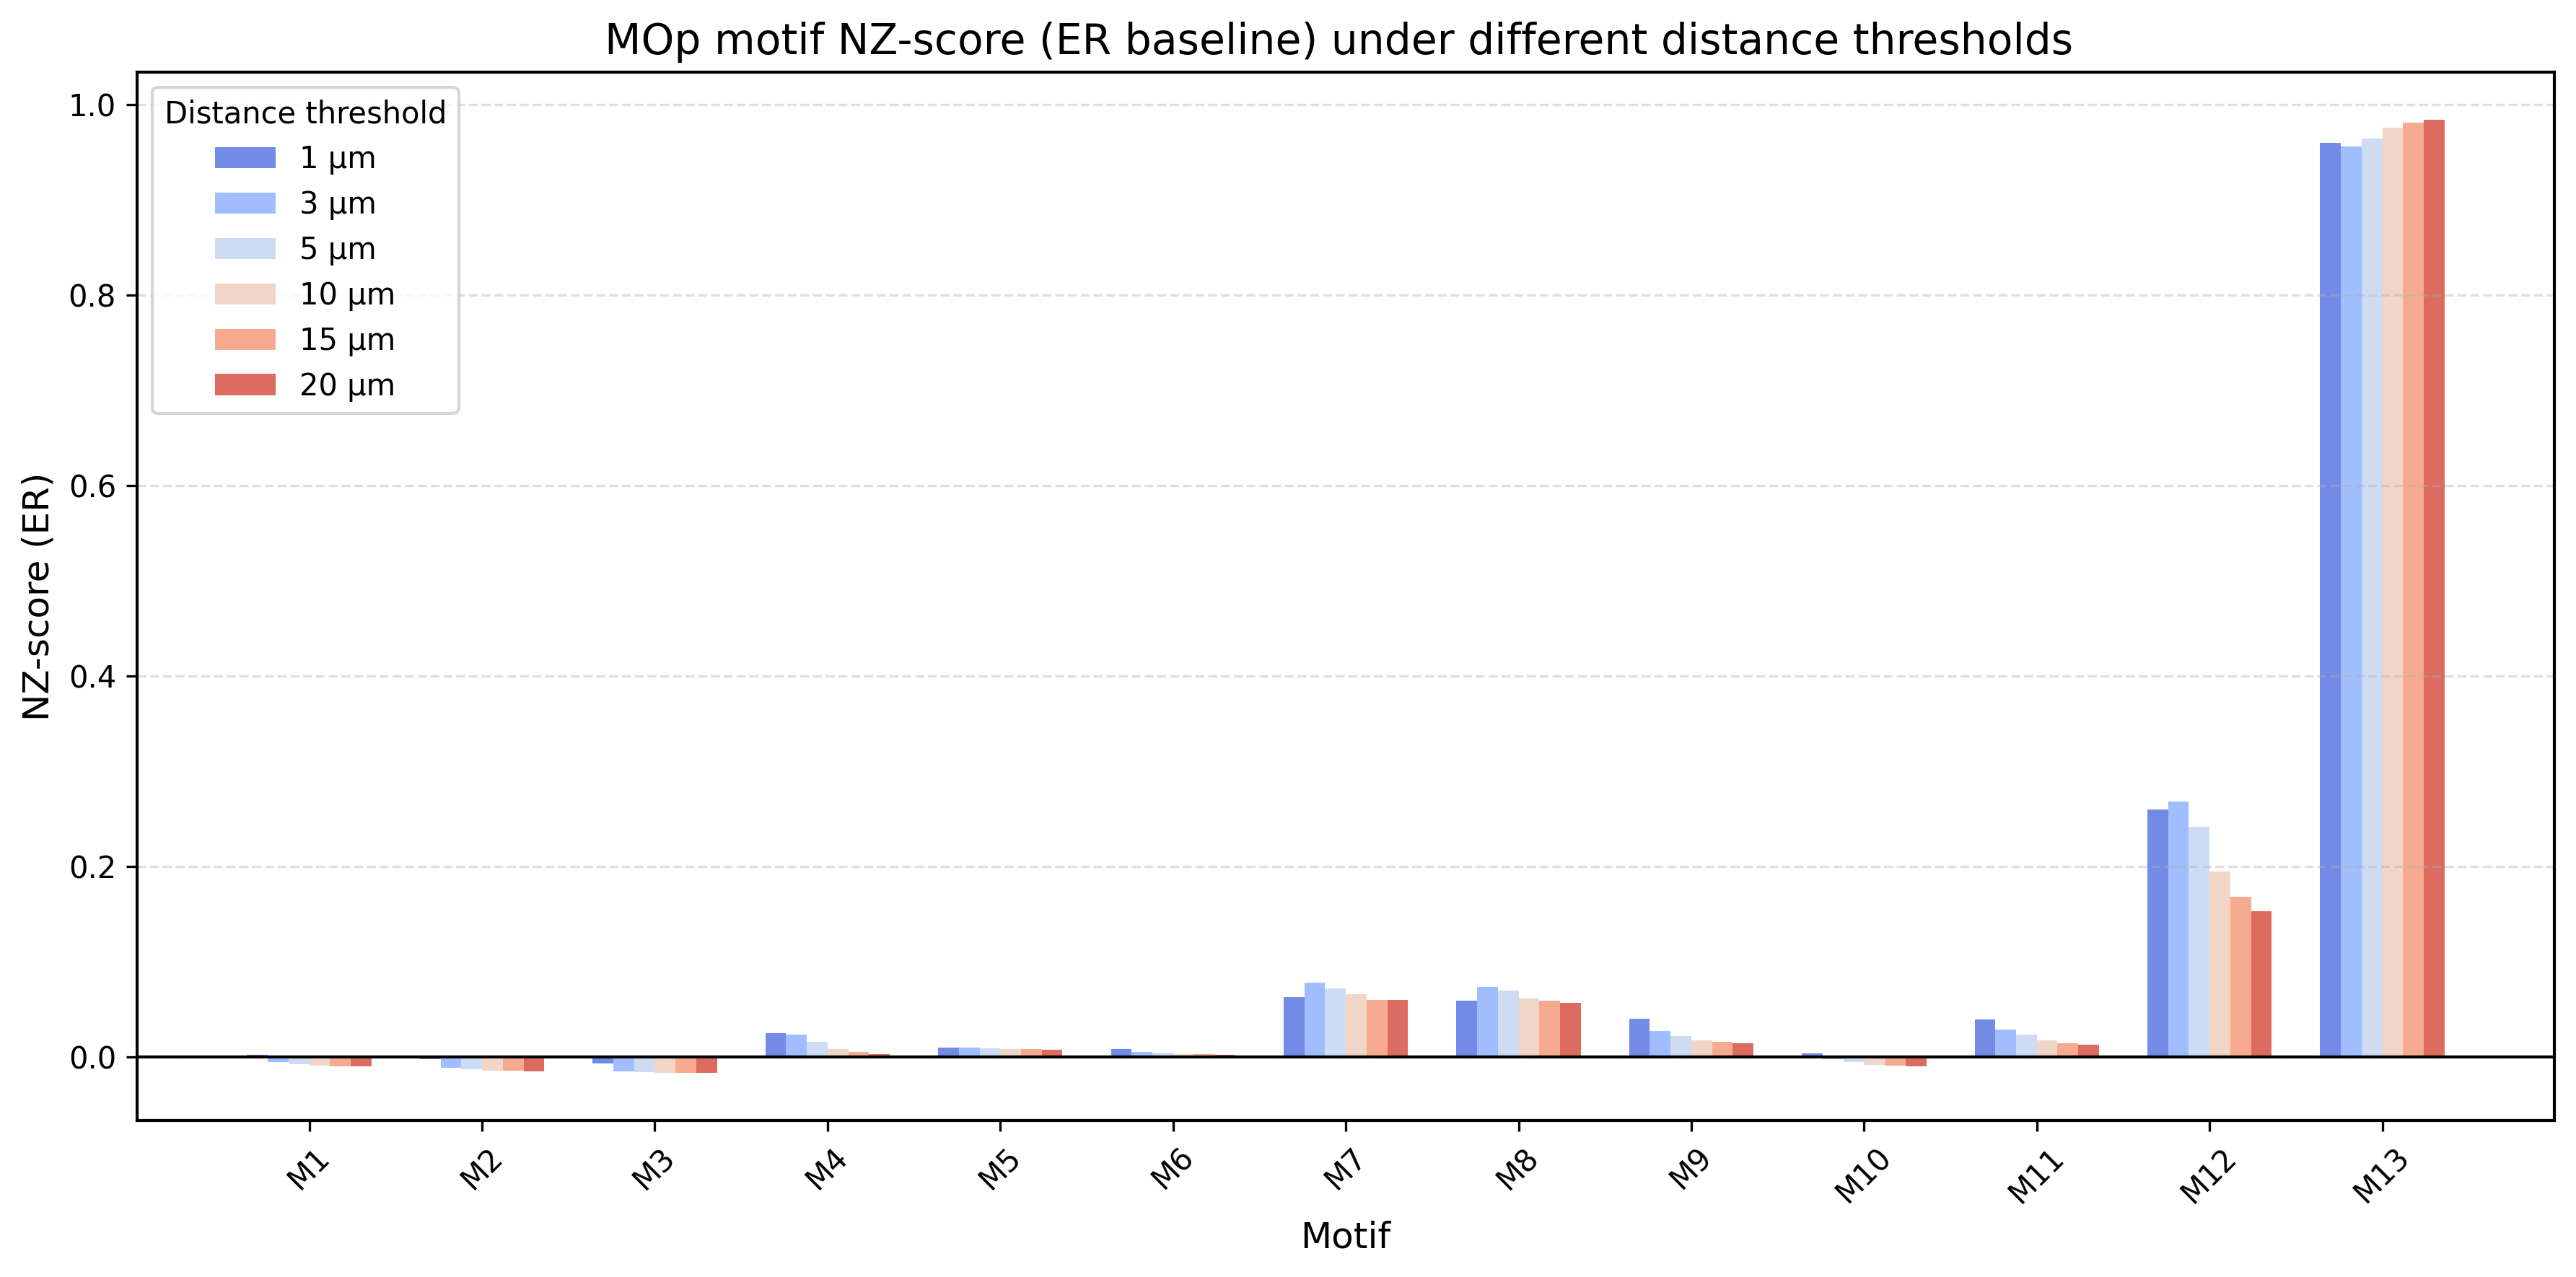

In [23]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ========= 0. 读数据 =========
pkl_path = "wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl"

with open(pkl_path, "rb") as f:
    d_all = pickle.load(f)

results = d_all["results"]   # dict: param -> {region -> info}


# ========= 1. 收集某个脑区在不同 param 下的 motif frequency & NZ =========

def collect_region_motif_across_params(region, params, thr_to_use="0"):
    """
    对指定 region，在多个距离阈值 param 下，收集：
      - freq: real_motif / sum(real_motif)
      - nz  : NZ_ER（优先用 NZ_raw，没有就用 NZ）
    返回:
      freq_dict[param] = 13 维数组
      nz_dict[param]   = 13 维数组
    """
    freq_dict = {}
    nz_dict   = {}

    for p in params:
        res_p = results.get(p, {})
        info = res_p.get(region, None)
        if info is None:
            print(f"[WARN] param={p} 下没有 region={region}")
            continue

        mr = info["motif_results"].get(thr_to_use, None)
        if mr is None:
            print(f"[WARN] param={p}, region={region} 下没有 thr={thr_to_use}")
            continue

        # ----- real_motif → 频率 -----
        real = np.asarray(mr["real_motif"], dtype=float)
        if real.shape[0] == 14:
            real = real[1:]
        if real.shape[0] != 13:
            print(f"[WARN] param={p}, region={region}: real_motif 维度异常: {real.shape}")
            continue

        total = real.sum()
        if total <= 0:
            print(f"[WARN] param={p}, region={region}: motif 总数为 0")
            continue

        freq = real / total

        # ----- NZ_ER：优先 NZ_raw，没有就用 NZ -----
        # if "NZ_raw" in mr:
        #     nz = np.asarray(mr["NZ_raw"], dtype=float)
        # else:
        nz = np.asarray(mr["NZ"], dtype=float)

        if nz.shape[0] == 14:
            nz = nz[1:]
        if nz.shape[0] != 13:
            print(f"[WARN] param={p}, region={region}: NZ 维度异常: {nz.shape}")
            continue

        freq_dict[p] = freq
        nz_dict[p]   = nz

    return freq_dict, nz_dict


# ========= 2. 画图：motif frequency / sum(motif) =========

def plot_region_freq_by_param(region, freq_dict, title_suffix=""):
    """
    freq_dict[param] = 13 维 freq
    多个 param 用多种颜色，在同一张图里画 grouped bar。
    """
    params = sorted(freq_dict.keys())  # 比如 [1,3,5,10,15,20]
    if not params:
        print(f"[ERROR] region={region} 的 freq_dict 为空，检查一下数据/阈值")
        return

    n_motif = len(next(iter(freq_dict.values())))
    x = np.arange(n_motif)
    order = list(range(1, n_motif + 1))

    bar_width = 0.12
    colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(params)))

    plt.figure(figsize=(12, 6))

    for j, p in enumerate(params):
        freq = freq_dict[p]

        plt.bar(
            x + j * bar_width,
            freq,
            width=bar_width,
            label=f"{p} µm",
            color=colors[j],
            alpha=0.85
        )

    plt.title(f'{region} motif frequency under different distance thresholds {title_suffix}',
              fontsize=14)
    plt.xlabel('Motif', fontsize=12)
    plt.ylabel('frequency (count / sum(count))', fontsize=12)
    plt.xticks(
        x + bar_width * (len(params) - 1) / 2,
        [f"M{i}" for i in order],
        rotation=45
    )
    plt.legend(title='Distance threshold')
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    fname = f'6.{region}_motif_frequency_vs_param.svg'
    plt.savefig(fname, format='svg', bbox_inches='tight')
    print("Saved figure:", fname)
    plt.show()


# ========= 3. 画图：NZ_ER（z-score, ER 基准） =========

def plot_region_NZ_by_param(region, nz_dict, title_suffix=""):
    """
    nz_dict[param] = 13 维 NZ_ER
    和 frequency 一样，用 grouped bar。
    """
    params = sorted(nz_dict.keys())
    if not params:
        print(f"[ERROR] region={region} 的 nz_dict 为空，检查一下数据/阈值")
        return

    n_motif = len(next(iter(nz_dict.values())))
    x = np.arange(n_motif)
    order = list(range(1, n_motif + 1))

    bar_width = 0.12
    colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(params)))

    plt.figure(figsize=(12, 6))

    for j, p in enumerate(params):
        nz = nz_dict[p]

        plt.bar(
            x + j * bar_width,
            nz,
            width=bar_width,
            label=f"{p} µm",
            color=colors[j],
            alpha=0.85
        )

    plt.title(f'{region} motif NZ-score (ER baseline) under different distance thresholds {title_suffix}',
              fontsize=14)
    plt.xlabel('Motif', fontsize=12)
    plt.ylabel('NZ-score (ER)', fontsize=12)
    plt.xticks(
        x + bar_width * (len(params) - 1) / 2,
        [f"M{i}" for i in order],
        rotation=45
    )
    plt.axhline(0, color='k', lw=1)
    plt.legend(title='Distance threshold')
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    fname = f'6.{region}_motif_NZ_ER_vs_param.svg'
    plt.savefig(fname, format='svg', bbox_inches='tight')
    print("Saved figure:", fname)
    plt.show()


# ========= 4. 调用：以 MOp 为例 =========

region = "MOp"
param_list = [1, 3, 5, 10, 15, 20]
thr_to_use = "0"   # 你现在用的强度阈值

freq_dict, nz_dict = collect_region_motif_across_params(region, param_list, thr_to_use=thr_to_use)

plot_region_freq_by_param(region, freq_dict)
plot_region_NZ_by_param(region, nz_dict)

In [37]:
# ===== 从 data 中按 names 顺序取出 ES，None 标记成 NaN =====
ES = np.full((len(names), 13), np.nan)

for i, r in enumerate(names):
    info = data[r]
    mr = info["motif_results"].get("0")   # 和前面一样的 thr_to_use
    es = mr.get("ES_raw", None)

    if es is None:
        continue  # 这一行保持 NaN，全 motif 都跳过
    es = np.asarray(es, float)
    if es.shape[0] != 13:
        continue

    ES[i, :] = es

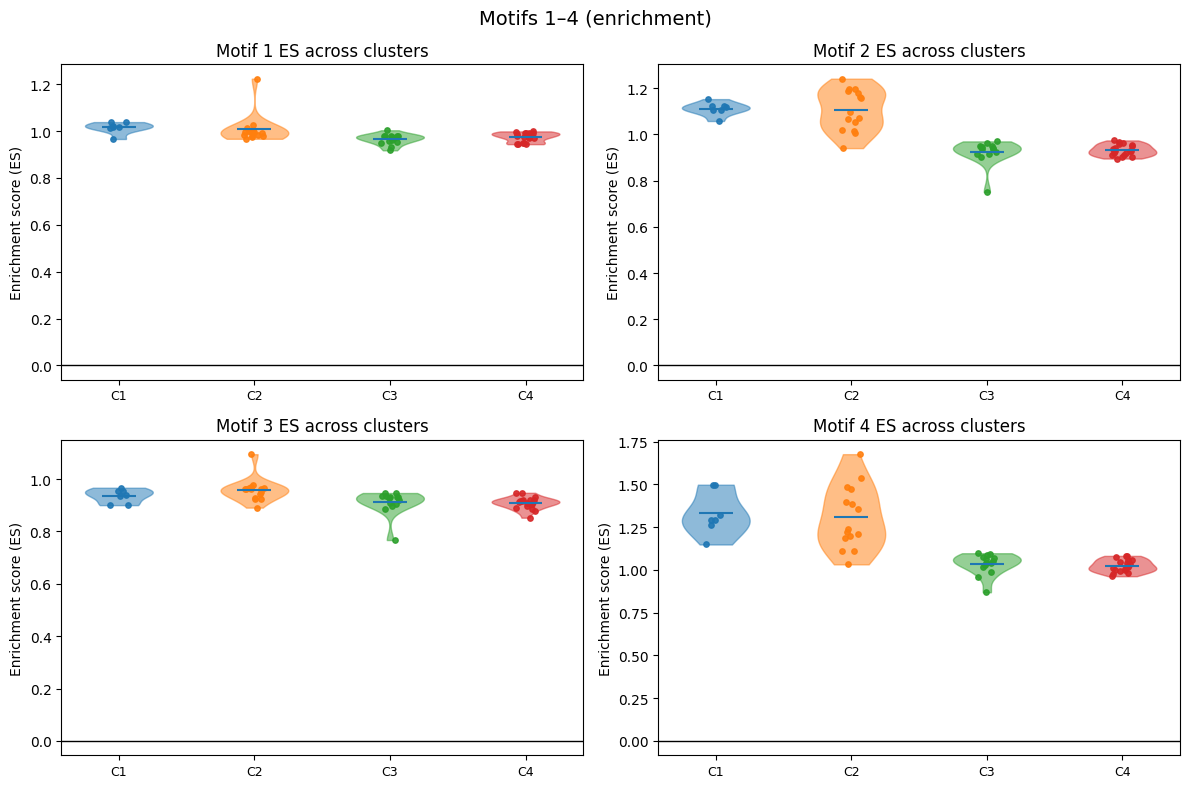

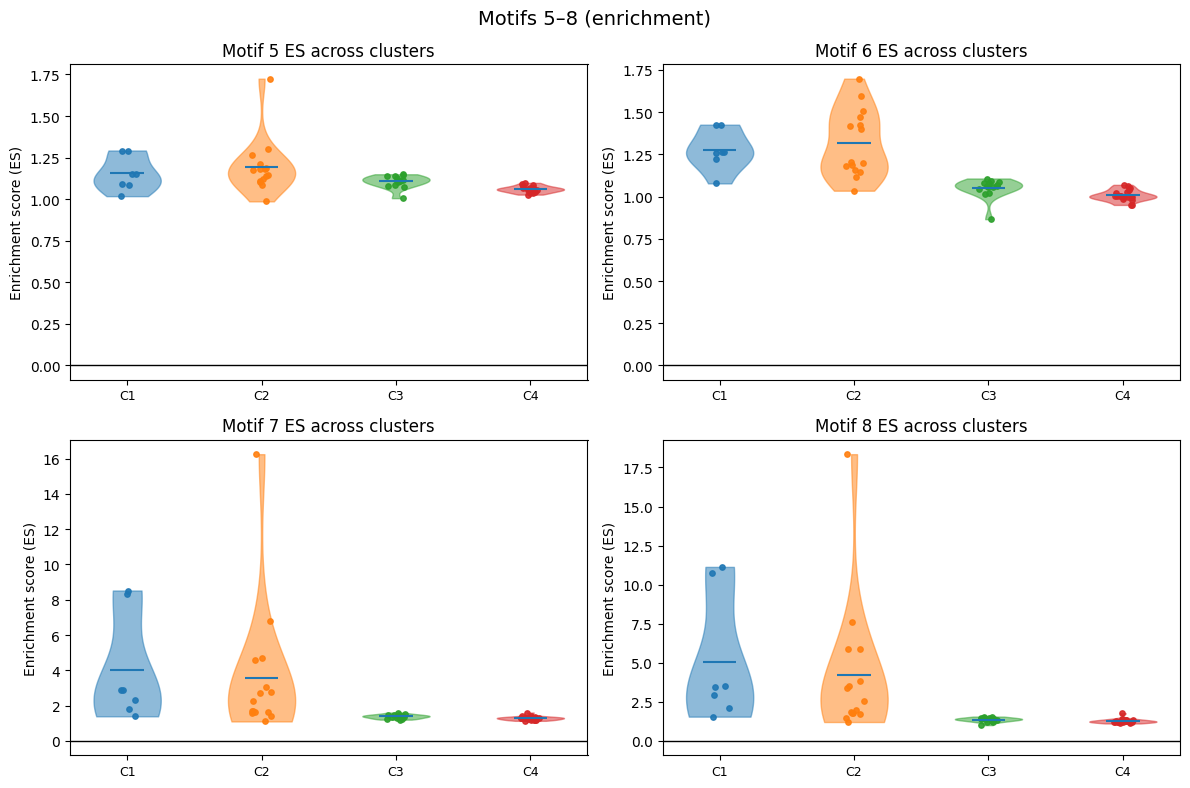

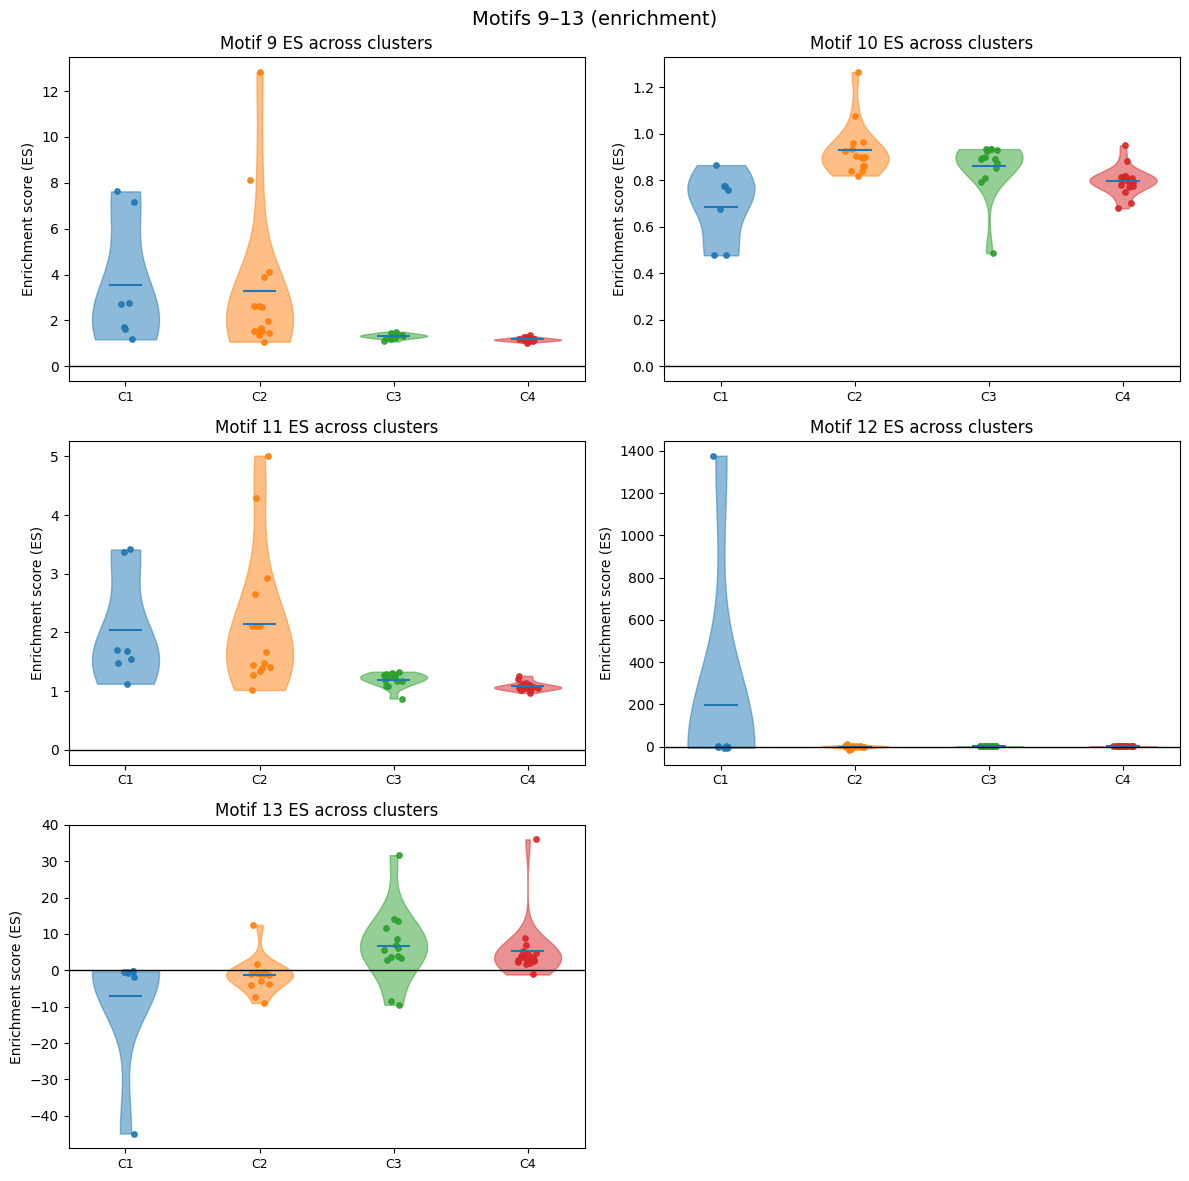

In [38]:
import matplotlib.pyplot as plt

unique_clusters = np.unique(labels)
n_clust = len(unique_clusters)
colors = plt.cm.tab10(np.arange(n_clust) % 10)  # 每个 cluster 一个颜色

motif_groups = [
    (list(range(0, 4)),  "Motifs 1–4 (enrichment)"),
    (list(range(4, 8)),  "Motifs 5–8 (enrichment)"),
    (list(range(8, 13)), "Motifs 9–13 (enrichment)"),
]

for motif_idx_list, title_group in motif_groups:
    n_motifs = len(motif_idx_list)
    n_cols = 2
    n_rows = int(np.ceil(n_motifs / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)

    for k, j in enumerate(motif_idx_list):
        row = k // n_cols
        col = k % n_cols
        ax = axes[row, col]

        vals = ES[:, j]  # 该 motif 的 enrichment，可能含 NaN
        # 如果这一列全是 NaN，就直接跳过
        if np.all(np.isnan(vals)):
            ax.set_visible(False)
            continue

        data_by_cluster = []
        for c in unique_clusters:
            mask_c = (labels == c) & ~np.isnan(vals)
            data_by_cluster.append(vals[mask_c])

        # ---- violin ----
        parts = ax.violinplot(
            data_by_cluster,
            positions=np.arange(1, n_clust + 1),
            showmeans=True,
            showextrema=False,
            showmedians=False,
        )

        # 统一 violin 颜色：每个 cluster 一个颜色
        for body, col_c in zip(parts['bodies'], colors):
            body.set_facecolor(col_c)
            body.set_edgecolor(col_c)
            body.set_alpha(0.5)

        # ---- 点：同色，同 cluster ----
        for i_c, c in enumerate(unique_clusters, start=1):
            mask_c = (labels == c) & ~np.isnan(vals)
            vals_c = vals[mask_c]
            if len(vals_c) == 0:
                continue
            jitter = (np.random.rand(len(vals_c)) - 0.5) * 0.15
            x_pos = np.full(len(vals_c), i_c) + jitter
            ax.scatter(x_pos, vals_c, s=15, alpha=0.9, color=colors[i_c-1])

        ax.set_xticks(np.arange(1, n_clust + 1))
        ax.set_xticklabels([f"C{int(c)}" for c in unique_clusters], fontsize=9)
        ax.axhline(0, color="k", lw=1)
        ax.set_ylabel("Enrichment score (ES)")
        ax.set_title(f"Motif {j+1} ES across clusters")

    # 删掉多余 subplot
    for k in range(n_motifs, n_rows * n_cols):
        row = k // n_cols
        col = k % n_cols
        fig.delaxes(axes[row, col])

    fig.suptitle(title_group, fontsize=14)
    plt.tight_layout()
    plt.show()

有 ES 的脑区数: 54  ES 形状: (54, 13)


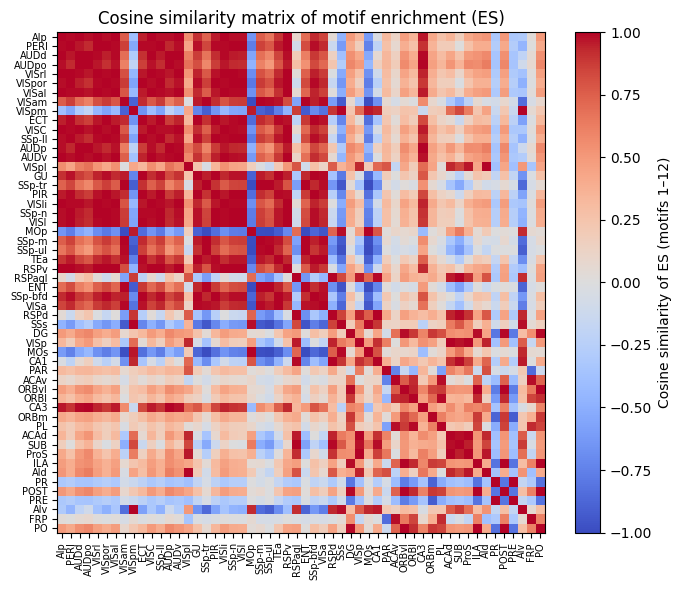

In [42]:
# ==================== ES：构建富集度矩阵（按 names 顺序） ====================
thr_to_use = "0.1"

ES_list = []
valid_mask = []

for r in names:
    info = data[r]
    mr = info["motif_results"].get(thr_to_use)
    es = mr.get("ES", None)
    if es is None:
        valid_mask.append(False)
        continue
    es = np.asarray(es, float)
    if es.shape[0] != 13:
        valid_mask.append(False)
        continue
    ES_list.append(es)
    valid_mask.append(True)

valid_mask = np.array(valid_mask, bool)

ES = np.vstack(ES_list)           # (n_valid_region, 13)
names_es = names[valid_mask]      # 只有有 ES 的脑区
labels_es = labels[valid_mask]

print("有 ES 的脑区数:", len(names_es), " ES 形状:", ES.shape)

# ==================== 富集度 ES 的余弦相似度（前 12 个 motif） ====================
X = ES[:, :13]                                  # 只用 motif 1–12
norms = np.linalg.norm(X, axis=1, keepdims=True)
X_norm = X / norms                              # 行归一化 → L2 = 1

cos_sim_es = X_norm @ X_norm.T                  # (n_valid_region, n_valid_region)

plt.figure(figsize=(7, 6))
im = plt.imshow(cos_sim_es, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="Cosine similarity of ES (motifs 1–12)")

plt.xticks(range(len(names_es)), names_es, rotation=90, fontsize=7)
plt.yticks(range(len(names_es)), names_es, fontsize=7)

plt.title("Cosine similarity matrix of motif enrichment (ES)")
plt.tight_layout()
plt.show()

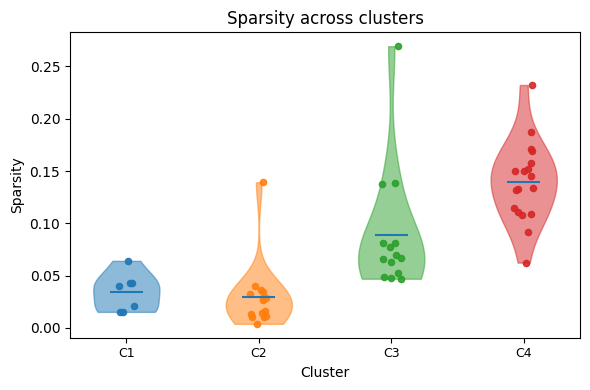

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# ==================== 不同聚类类别的稀疏度 ====================
unique_clusters = np.unique(labels)
n_clust = len(unique_clusters)

vals = spars  # 每个脑区的稀疏度

data_by_cluster = [vals[labels == c] for c in unique_clusters]

plt.figure(figsize=(6, 4))

# 1) violin
parts = plt.violinplot(
    data_by_cluster,
    positions=np.arange(1, n_clust + 1),
    showmeans=True,
    showextrema=False,
    showmedians=False,
)

colors = plt.cm.tab10(np.arange(n_clust) % 10)
for body, col_c in zip(parts["bodies"], colors):
    body.set_facecolor(col_c)
    body.set_edgecolor(col_c)
    body.set_alpha(0.5)

# 2) 叠加散点（每个脑区一个点，颜色与对应 cluster 一致）
for i, c in enumerate(unique_clusters, start=1):
    mask_c = (labels == c)
    vals_c = vals[mask_c]
    if len(vals_c) == 0:
        continue
    jitter = (np.random.rand(len(vals_c)) - 0.5) * 0.15
    x_pos = np.full(len(vals_c), i) + jitter
    plt.scatter(x_pos, vals_c, s=20, alpha=0.9, color=colors[i-1])

plt.xticks(
    np.arange(1, n_clust + 1),
    [f"C{int(c)}" for c in unique_clusters],
    fontsize=9,
)
plt.ylabel("Sparsity")
plt.xlabel("Cluster")
plt.title("Sparsity across clusters")

plt.tight_layout()
plt.show()

In [49]:
param_to_use = 5
thr_to_use   = "0.1"

with open("wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl", "rb") as f:
    d = pickle.load(f)

res_param = d["results"][param_to_use]

# 之前已经算好的：
# NZ, names, labels, spars, ...

# ===== 1. 基于原始 sc 计算每个脑区的平均出度 / 入度 =====
thr_val = float(thr_to_use)

deg_out = np.zeros(len(names))
deg_in  = np.zeros(len(names))

for i, r in enumerate(names):
    info = res_param[r]
    sc = np.asarray(info["sc"], float)   # 原始强度矩阵
    A = (sc > 0).astype(float)     # 按强度阈值二值化
    np.fill_diagonal(A, 0.0)             # 不算自连接

    deg_out_nodes = A.sum(axis=1)        # 每个节点的出度
    deg_in_nodes  = A.sum(axis=0)        # 每个节点的入度

    # 每个脑区一个平均出度 / 入度（也可以换成中位数）
    deg_out[i] = deg_out_nodes.mean()
    deg_in[i]  = deg_in_nodes.mean()

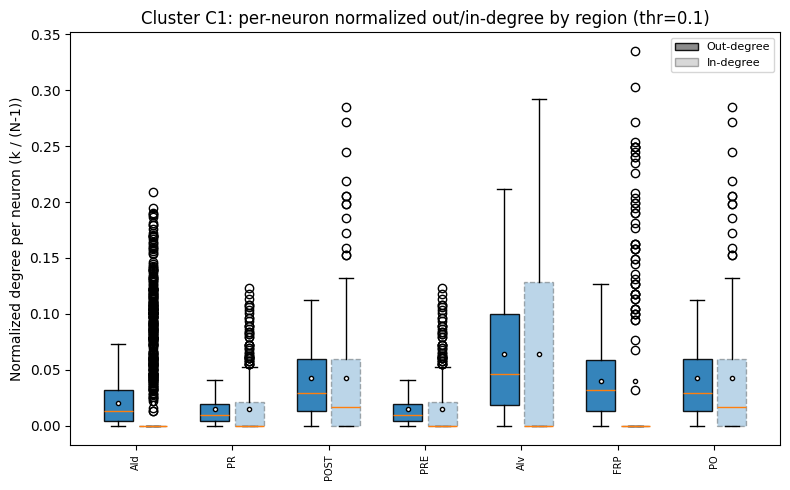

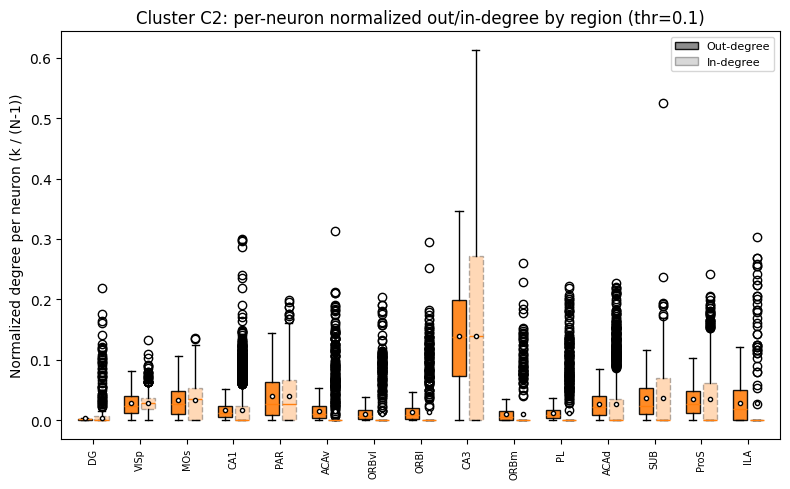

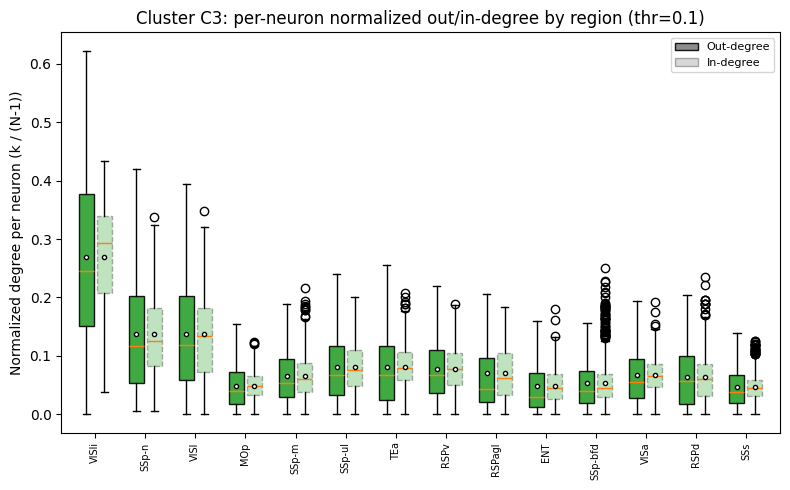

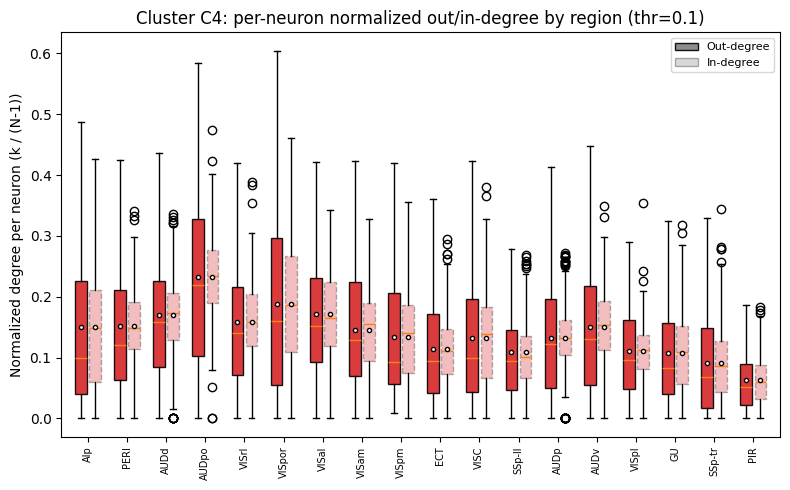

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ==================== 1. 基于 sc 计算归一化出入度分布 ====================
thr_val = float(thr_to_use)

out_deg_norm_list = []   # 每个元素：该脑区所有神经元的归一化出度 k_out/(N-1)
in_deg_norm_list  = []   # 每个元素：该脑区所有神经元的归一化入度 k_in/(N-1)

for r in names:
    info = res_param[r]
    sc = np.asarray(info["sc"], float)   # 原始强度矩阵 (N_i, N_i)

    # 按强度阈值二值化
    A = (sc > 0.0).astype(float)
    np.fill_diagonal(A, 0.0)

    N = A.shape[0]
    if N <= 1:
        out_deg_norm_list.append(np.array([]))
        in_deg_norm_list.append(np.array([]))
        continue

    deg_out_nodes = A.sum(axis=1)        # 每个神经元出度
    deg_in_nodes  = A.sum(axis=0)        # 每个神经元入度

    # 归一化：除以 (N-1)，消除采样规模 N 的影响
    out_deg_norm = deg_out_nodes / (N - 1)
    in_deg_norm  = deg_in_nodes  / (N - 1)

    out_deg_norm_list.append(out_deg_norm)
    in_deg_norm_list.append(in_deg_norm)

# ==================== 2. 四类 cluster，各画一张箱线图（无 outlier） ====================
unique_clusters = np.unique(labels)
colors_cluster = plt.cm.tab10((unique_clusters - 1) % 10)  # 每个 cluster 一个颜色

for c, col_c in zip(unique_clusters, colors_cluster):
    # 找到属于该 cluster 的脑区索引
    idx = np.where(labels == c)[0]
    if len(idx) == 0:
        continue

    region_names_c = names[idx]
    out_c = [out_deg_norm_list[i] for i in idx]
    in_c  = [in_deg_norm_list[i]  for i in idx]

    # 过滤掉可能为空的脑区（例如 N<=1）
    valid = [i for i, (o, inn) in enumerate(zip(out_c, in_c)) if len(o) > 0 and len(inn) > 0]
    if not valid:
        continue

    region_names_c = region_names_c[valid]
    out_c = [out_c[i] for i in valid]
    in_c  = [in_c[i]  for i in valid]

    n_regions_c = len(region_names_c)
    x = np.arange(n_regions_c)

    fig, ax = plt.subplots(figsize=(max(8, n_regions_c * 0.4), 5))

    # 出度箱线图（在 x-0.18），不显示 outlier
    bp_out = ax.boxplot(
        out_c,
        positions=x - 0.18,
        widths=0.3,
        patch_artist=True,
        showmeans=True,
        showfliers=False,
    )

    # 入度箱线图（在 x+0.18），不显示 outlier
    bp_in = ax.boxplot(
        in_c,
        positions=x + 0.18,
        widths=0.3,
        patch_artist=True,
        showmeans=True,
        showfliers=True,
    )

    # 出度：该 cluster 的颜色，实心
    for box in bp_out["boxes"]:
        box.set(facecolor=col_c, edgecolor="k", alpha=0.9)
    # 入度：同色，但淡一点 + 虚线边框
    for box in bp_in["boxes"]:
        box.set(facecolor=col_c, edgecolor="k", alpha=0.3, linestyle="--")

    # 均值点强调一下
    for m in bp_out["means"]:
        m.set(marker="o", markersize=3, markerfacecolor="white", markeredgecolor="k")
    for m in bp_in["means"]:
        m.set(marker="o", markersize=3, markerfacecolor="white", markeredgecolor="k")

    ax.set_xticks(x)
    ax.set_xticklabels(region_names_c, rotation=90, fontsize=7)

    ax.set_ylabel("Normalized degree per neuron (k / (N-1))")
    ax.set_title(f"Cluster C{int(c)}: per-neuron normalized out/in-degree by region (thr={thr_to_use})")

    legend_patches = [
        Patch(facecolor="gray", edgecolor="k", alpha=0.9, label="Out-degree"),
        Patch(facecolor="gray", edgecolor="k", alpha=0.3, label="In-degree"),
    ]
    ax.legend(handles=legend_patches, loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()

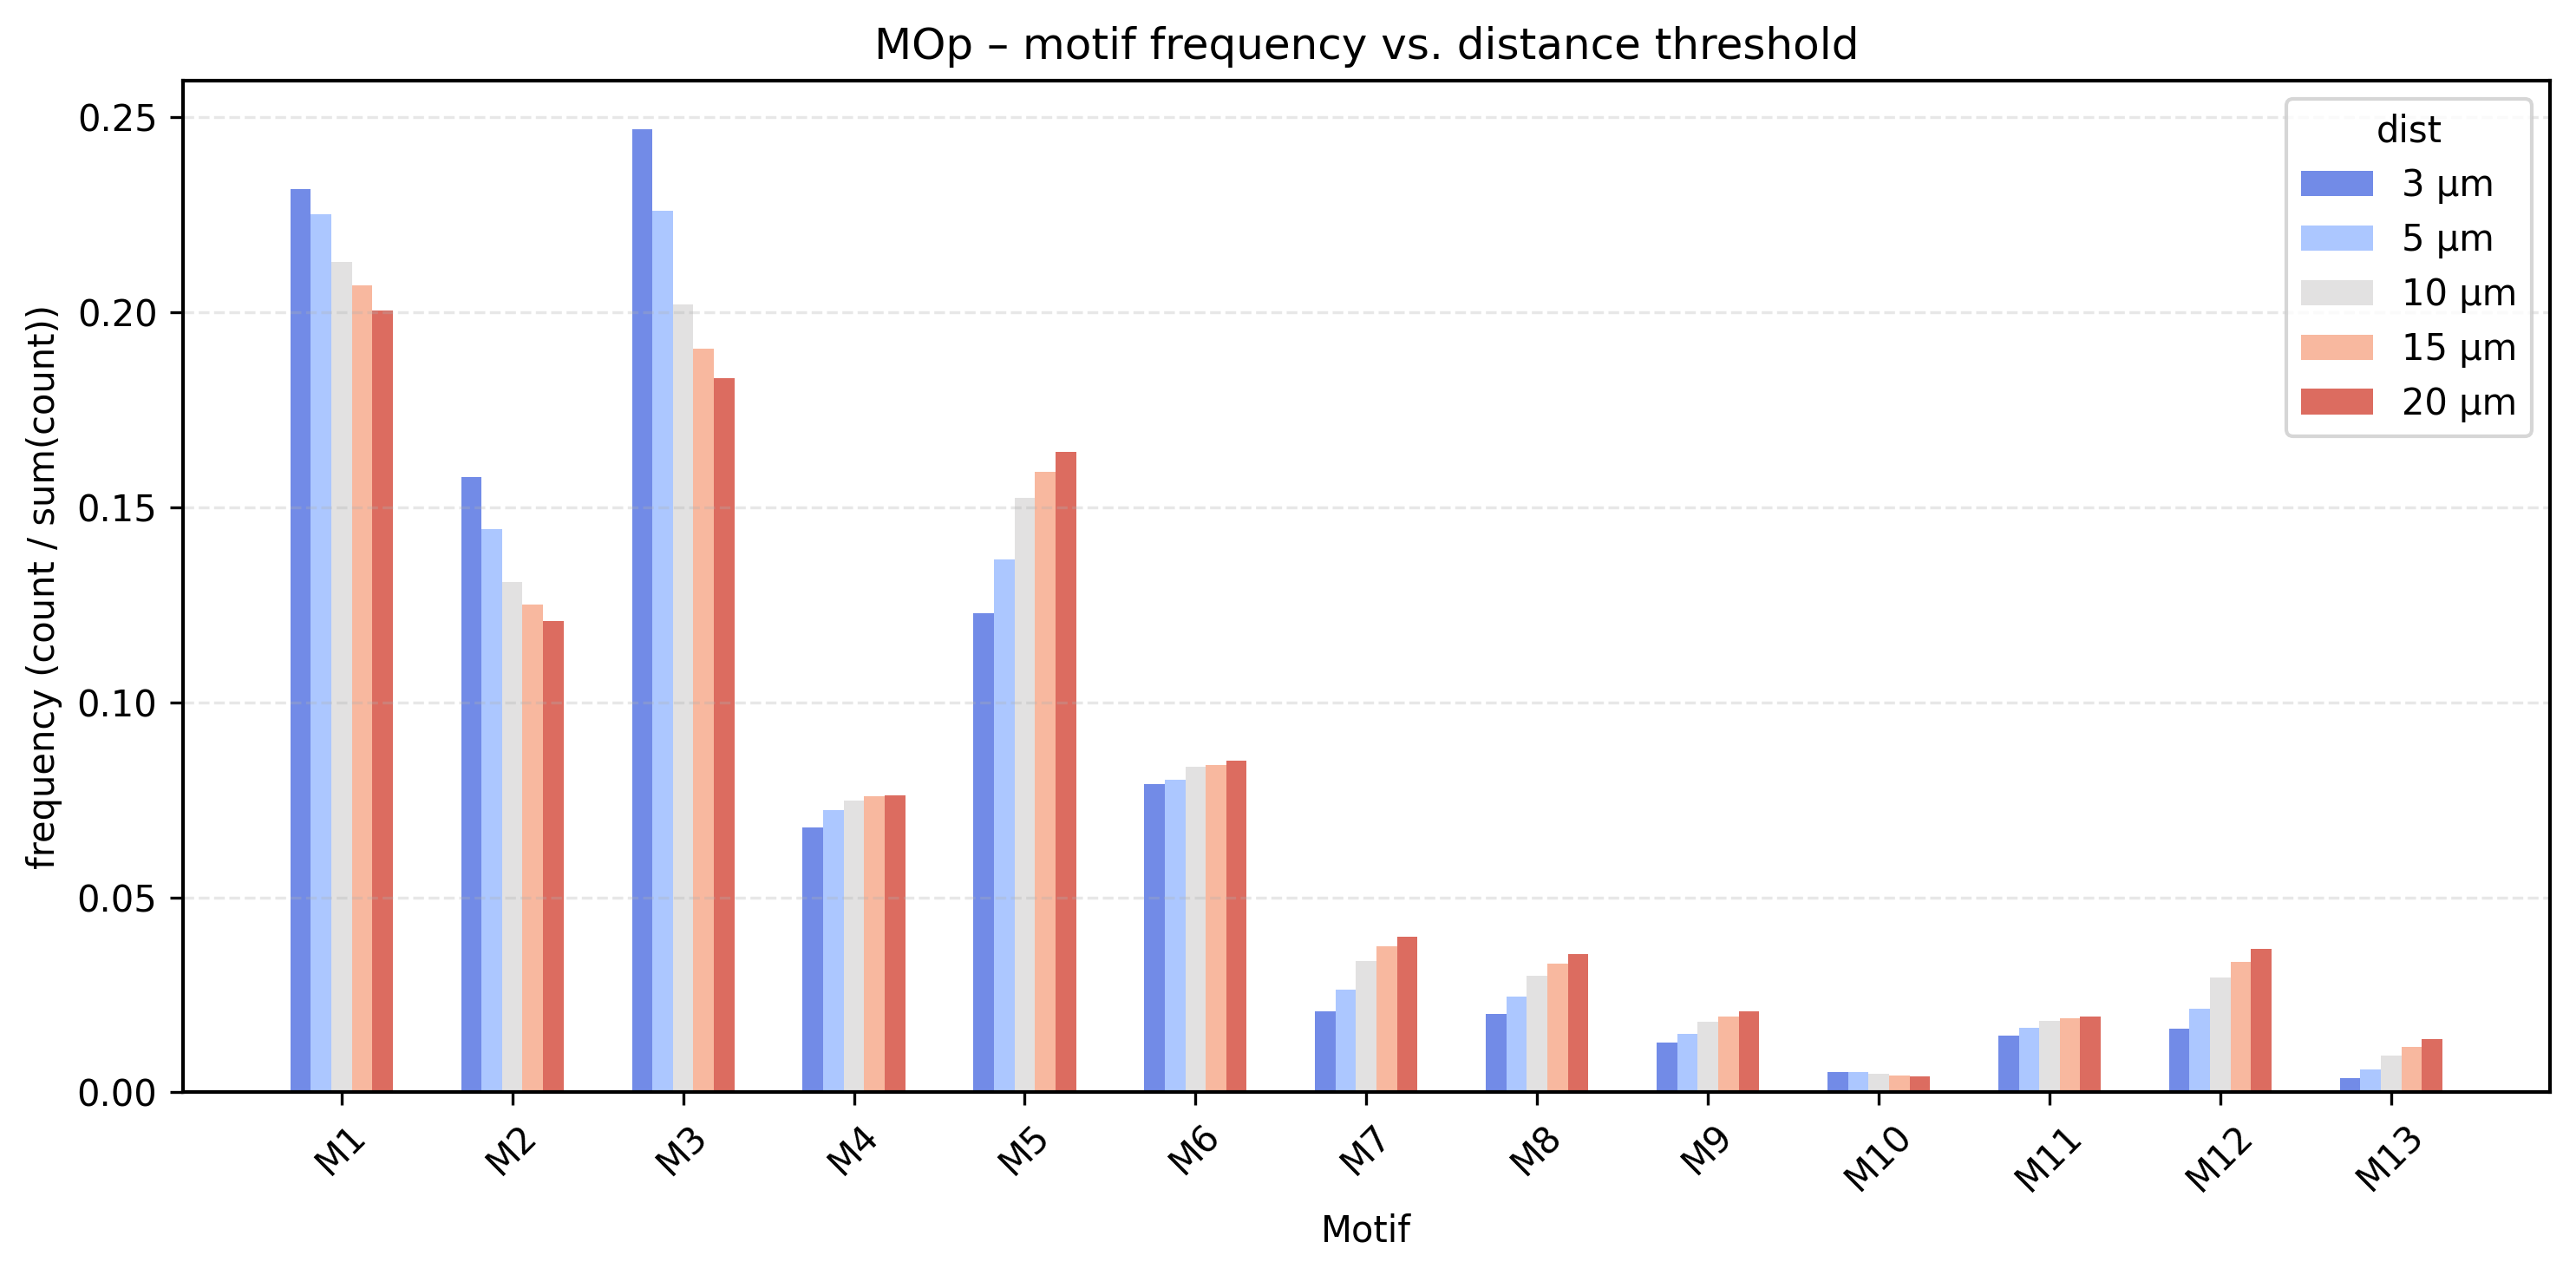

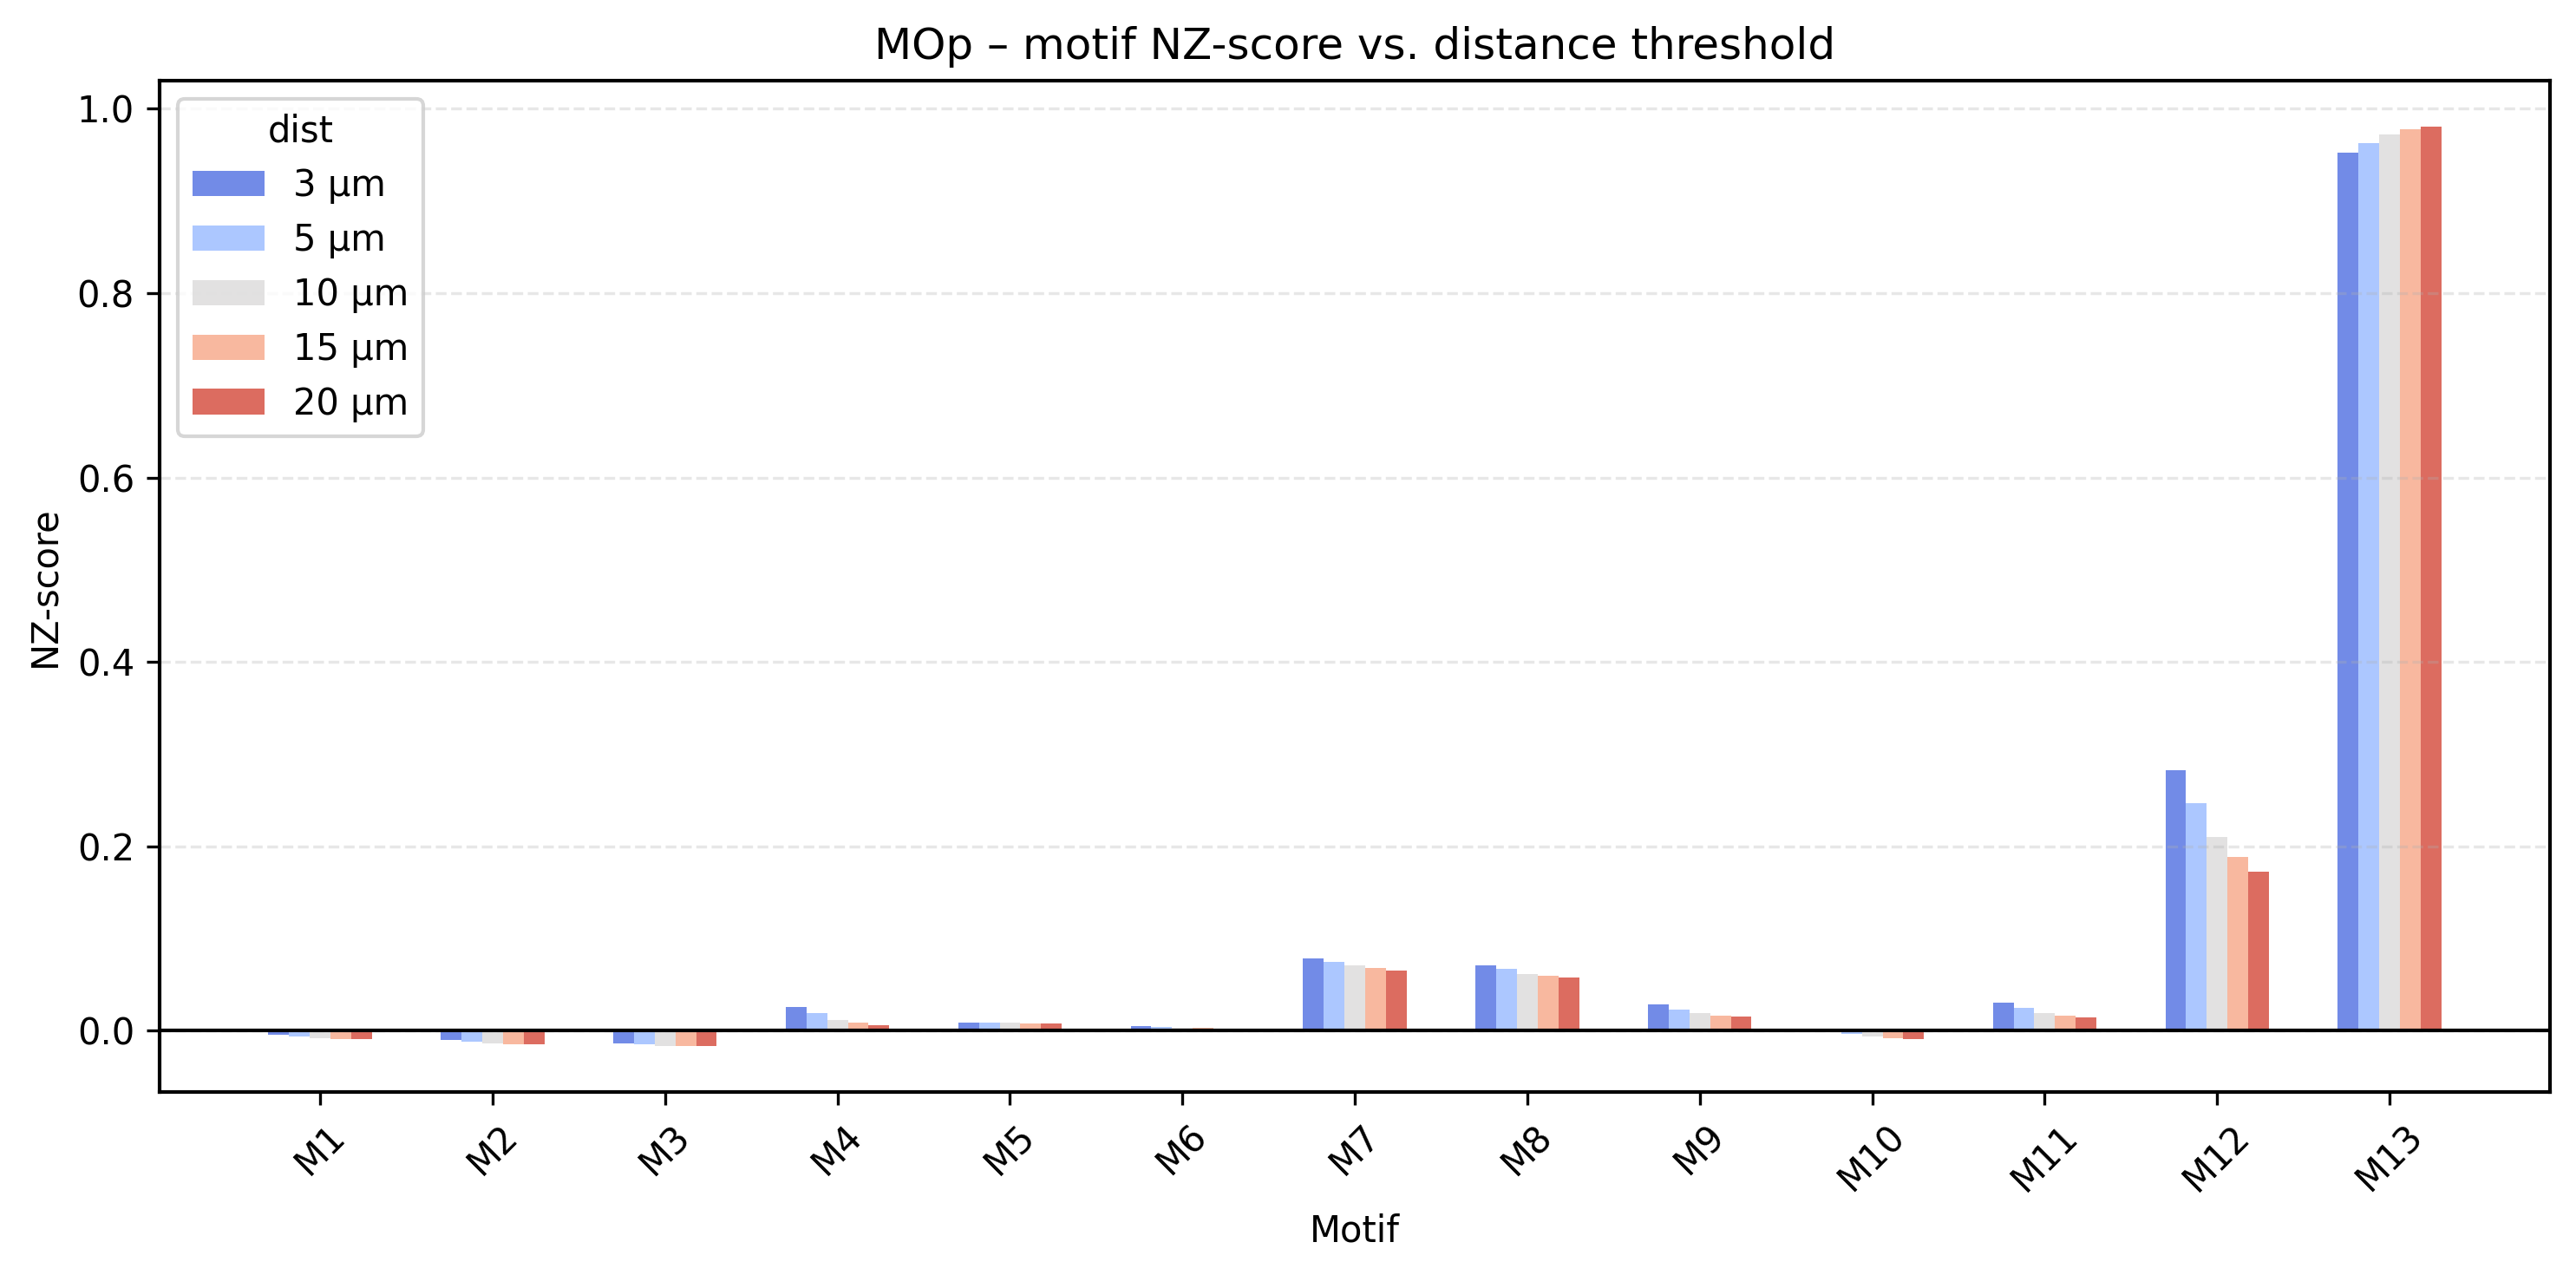

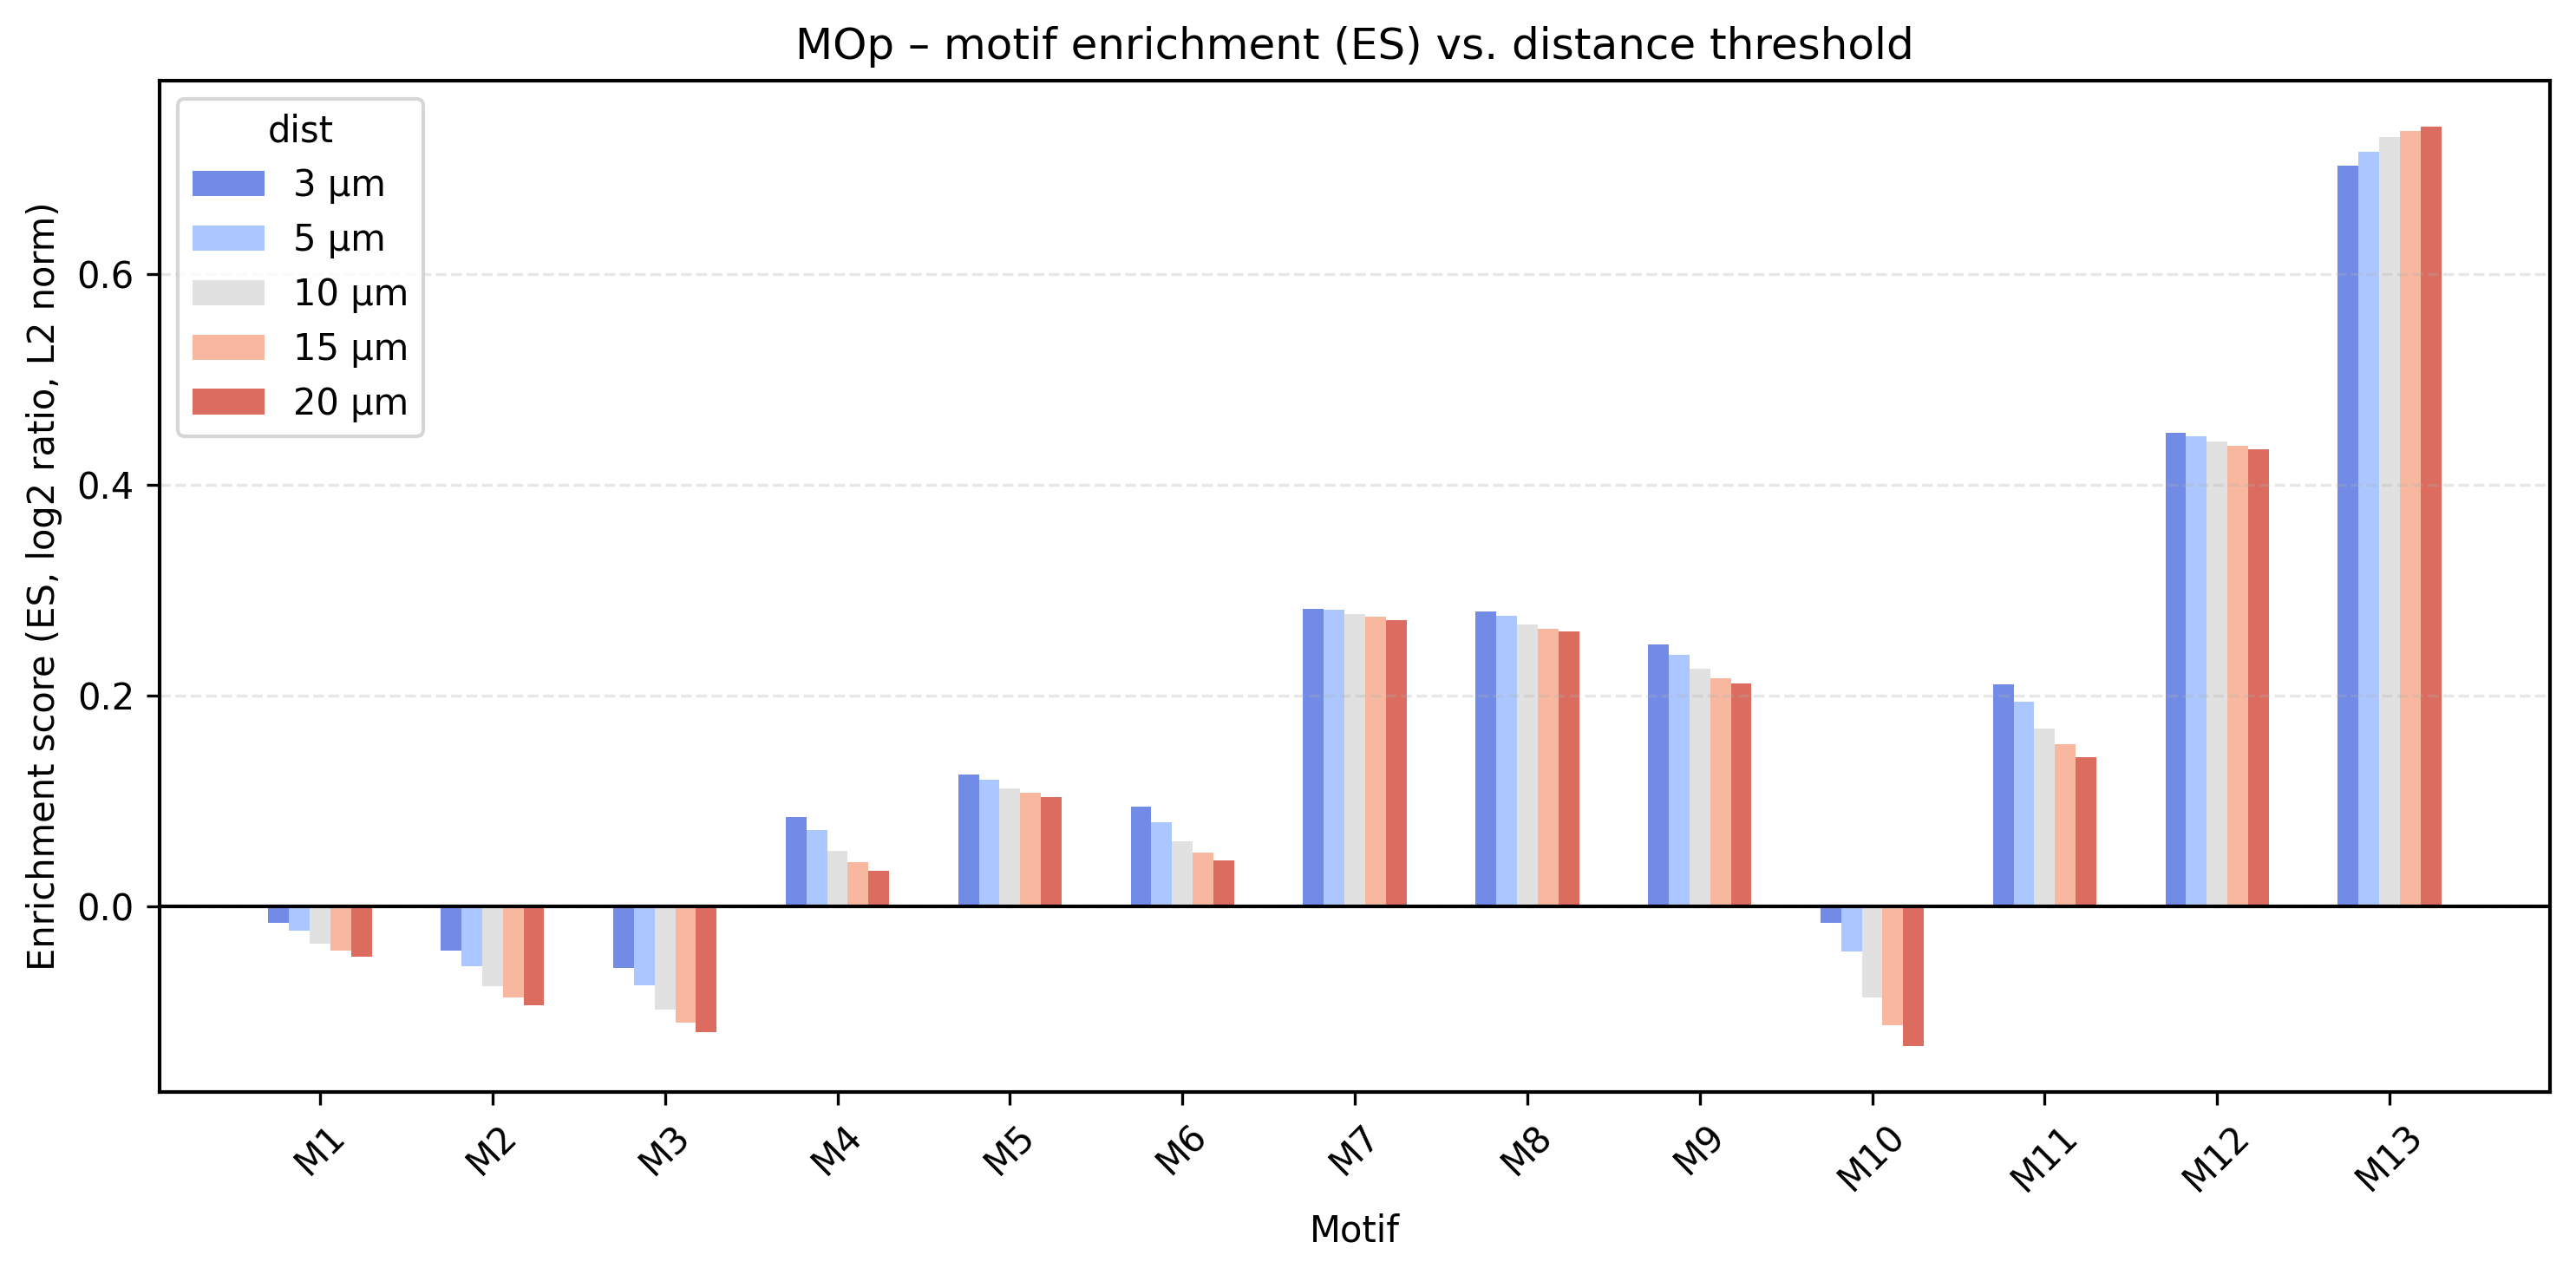

In [24]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ===== 0. 基本参数 =====
pkl_path   = "wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl"
region     = "MOp"                 # 换成你想看的脑区
param_list = [ 3, 5, 10, 15, 20] # 不同距离阈值
thr        = "0.1"                   # motif_results 的 key

# ===== 1. 读数据 =====
with open(pkl_path, "rb") as f:
    results = pickle.load(f)["results"]   # dict[param][region]["motif_results"][thr]

freq_dict = {}
nz_dict   = {}
es_dict   = {}

for p in param_list:
    mr = results[p][region]["motif_results"][thr]

    # ---- 频率：real_motif / sum ----
    real = np.asarray(mr["real_motif"], float)
    freq_dict[p] = real / real.sum()

    # ---- NZ ----
    nz = np.asarray(mr["NZ"], float)
    nz_dict[p] = nz

    # ---- ES：用你指定的公式重算 ----
    # es_raw = log2(real) - log2(mu_eq), 然后 L2 归一化
    mu_eq  = np.asarray(mr["er_mu_eq"], float)
    es_raw = np.log2(real) - np.log2(mu_eq)
    es_norm = es_raw / np.linalg.norm(es_raw)
    es_dict[p] = es_norm

# 公共横坐标
x  = np.arange(13)
bw = 0.12

# ===== 2. 画 freq（motif frequency / sum）=====
params_freq = sorted(freq_dict.keys())
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(params_freq)))

plt.figure(figsize=(10, 5))
for i, p in enumerate(params_freq):
    plt.bar(x + i*bw, freq_dict[p], width=bw,
            alpha=0.85, color=colors[i], label=f"{p} µm")
plt.xticks(x + bw*(len(params_freq)-1)/2,
           [f"M{i}" for i in range(1, 14)], rotation=45)
plt.ylabel("frequency (count / sum(count))")
plt.xlabel("Motif")
plt.title(f"{region} – motif frequency vs. distance threshold")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="dist")
plt.tight_layout()
plt.savefig(f"6.{region}_motif_frequency_vs_param.svg",
                 bbox_inches="tight", transparent=True)
plt.show()

# ===== 3. 画 NZ =====
params_nz = sorted(nz_dict.keys())
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(params_freq)))

plt.figure(figsize=(10, 5))
for i, p in enumerate(params_nz):
    plt.bar(x + i*bw, nz_dict[p], width=bw,
            alpha=0.85, color=colors[i], label=f"{p} µm")
plt.xticks(x + bw*(len(params_nz)-1)/2,
           [f"M{i}" for i in range(1, 14)], rotation=45)
plt.axhline(0, color="k", lw=1)
plt.ylabel("NZ-score")
plt.xlabel("Motif")
plt.title(f"{region} – motif NZ-score vs. distance threshold")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="dist")
plt.tight_layout()
plt.savefig(f"6.{region}_motif_NZ_vs_param.svg",
                 bbox_inches="tight", transparent=True)
plt.show()

# ===== 4. 画 ES（用新公式计算的 ES_norm）=====
params_es = sorted(es_dict.keys())
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(params_freq)))

plt.figure(figsize=(10, 5))
for i, p in enumerate(params_es):
    plt.bar(x + i*bw, es_dict[p], width=bw,
            alpha=0.85, color=colors[i], label=f"{p} µm")
plt.xticks(x + bw*(len(params_es)-1)/2,
           [f"M{i}" for i in range(1, 14)], rotation=45)
plt.axhline(0, color="k", lw=1)
plt.ylabel("Enrichment score (ES, log2 ratio, L2 norm)")
plt.xlabel("Motif")
plt.title(f"{region} – motif enrichment (ES) vs. distance threshold")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="dist")
plt.tight_layout()
plt.savefig(f"6.{region}_motif_ES_vs_param.svg",
                 bbox_inches="tight", transparent=True)
plt.show()